<a href="https://colab.research.google.com/github/Ganeshiny/cancer-rna-seq/blob/main/script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tumor Classification from RNA-Seq Gene Expression

**Dataset:** TCGA-PANCAN-HiSeq `801 x 20531` (UCI / Kaggle *Gene Expression Cancer RNA-Seq*)
**Task:** Multi-class classification of tumor type (`BRCA`, `KIRC`, `COAD`, `LUAD`, `PRAD`) from per-sample gene expression.
**Models:** Random Forest baseline → regularized PyTorch MLP → VAE-compressed latent + classifier.


## 0. Setup, configuration, and reproducibility

In [3]:
import os, random, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Paths / config (override via environment variables if needed) ----
#DATA_DIR     = Path(os.environ.get("RNASEQ_DATA_DIR", "./data"))
#ARTIFACT_DIR = Path("./artifacts"); ARTIFACT_DIR.mkdir(exist_ok=True)

'''
TOP_K_GENES = 2000 # genes kept after train-only variance filter
MLP_EPOCHS  = int(os.environ.get("MLP_EPOCHS", 300))
VAE_EPOCHS  = int(os.environ.get("VAE_EPOCHS", 300))
PATIENCE    = 30 # early-stopping patience (epochs)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
PALETTE = "Set2"

print("Device:", DEVICE, "| torch", torch.__version__)
print("Data dir:", DATA_DIR.resolve())
'''

'\nTOP_K_GENES = 2000 # genes kept after train-only variance filter\nMLP_EPOCHS  = int(os.environ.get("MLP_EPOCHS", 300))\nVAE_EPOCHS  = int(os.environ.get("VAE_EPOCHS", 300))\nPATIENCE    = 30 # early-stopping patience (epochs)\n\nsns.set_theme(style="whitegrid", context="talk")\nplt.rcParams["figure.dpi"] = 110\nPALETTE = "Set2"\n\nprint("Device:", DEVICE, "| torch", torch.__version__)\nprint("Data dir:", DATA_DIR.resolve())\n'

## 1. Dataset

This collection of data is part of the RNA-Seq (HiSeq) PANCAN data set, it is a random extraction of gene expressions of patients having different types of tumor: BRCA, KIRC, COAD, LUAD and PRAD.

| **Code** | **Tumor Name**                             |
| -------- | ------------------------------------------ |
| BRCA     | Breast invasive carcinoma (breast cancer)  |
| KIRC     | Kidney renal clear cell carcinoma (kidney) |
| COAD     | Colon adenocarcinoma (colon)               |
| LUAD     | Lung adenocarcinoma (lung)                 |
| PRAD     | Prostate adenocarcinoma (prostate)         |


=801 (rows: samples) x 20531 (cols: features)=

Samples (instances) are stored row-wise. Variables (attributes) of each sample are RNA-Seq gene expression levels measured by illumina HiSeq platform.

This dataset has **no missing values**

Values are continuous and already on a normalized/log-like scale.
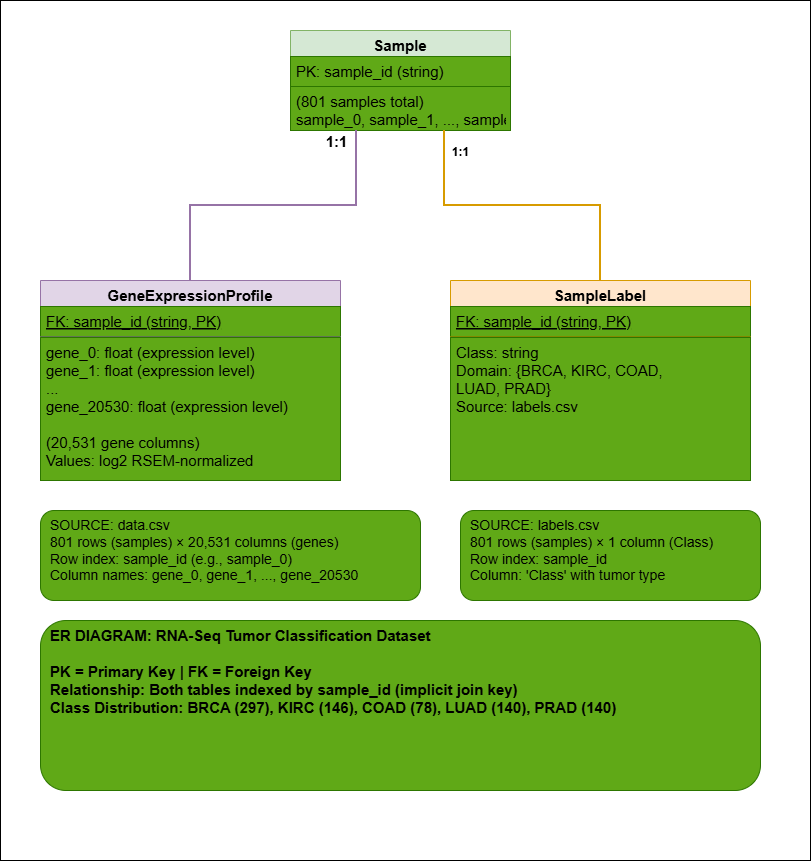

## 2. Problem

**Given a vector of 20,531 gene-expression values for one patient sample, predict which of five tumor types it is. Output is a single categorical label (one of 5) plus class probabilities (multiclass classification)**


This is a $p \gg n$ problem: $p = 20{,}531$ features against $n = 801$ samples (~25 features per sample).

So what my problems would be are: **overfitting** and **information leakage from preprocessing**

## 3. How was evaluation done

 Stratified 60/20/20 train/validation/test split. The validation split is used for model selection and early stopping; the **test split is evaluated once** at the end.

 Because classes are imbalanced (see EDA)

 The most important reported metric is **macro-F1** (equal weight per class)

 Other metrics reported alongside are:

1. Accuracy
2. weighted F1
3. per class precision/recall
4. confusion metrics
5. one-vs-rest ROC AUC (Receiver operating curve, area under curve)



## 4. Loading and viewing the data

There are two data files in the `./data` directory:
1.   `data.csv`: stores samples row-wise (first column = sample id, remaining columns = genes).
2.   `labels.csv`:  maps each sample id to its `Class`.

In [4]:
from google.colab import drive
import os
from pathlib import Path

# 1. Mount the base Google Drive filesystem
drive.mount('/content/drive')

# 2. Point to your specific project folder inside Google Drive
DATA_DIR = Path('/content/drive/MyDrive/cancer-rna-seq/data')
ARTIFACT_DIR = Path("./artifacts"); ARTIFACT_DIR.mkdir(exist_ok=True)

TOP_K_GENES = 2000 # genes kept after train-only variance filter
MLP_EPOCHS  = int(os.environ.get("MLP_EPOCHS", 300))
VAE_EPOCHS  = int(os.environ.get("VAE_EPOCHS", 300))
PATIENCE    = 30 # early-stopping patience (epochs)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
PALETTE = "Set2"

print("Device:", DEVICE, "| torch", torch.__version__)
print("Data dir:", DATA_DIR.resolve())

Mounted at /content/drive
Device: cuda | torch 2.11.0+cu128
Data dir: /content/drive/MyDrive/cancer-rna-seq/data


In [5]:
data_path   = DATA_DIR / "data.csv"
labels_path = DATA_DIR / "labels.csv"

X      = pd.read_csv(data_path, index_col=0)        # rows = samples, cols = gene_0..gene_20530
print(X.head())
labels = pd.read_csv(labels_path, index_col=0)
print(labels.head())
y_raw  = labels["Class"]

# Align labels to the feature matrix on the sample id index.
assert set(X.index) == set(y_raw.index), "Sample ids in data.csv and labels.csv do not match"
y_raw = y_raw.loc[X.index]                          # enforce identical ordering

print(f"Feature matrix : {X.shape[0]} samples x {X.shape[1]} genes")
print(f"Labels         : {y_raw.shape[0]} samples, {y_raw.nunique()} classes")
print("Classes        :", sorted(y_raw.unique()))
X.iloc[:5, :6]

          gene_0    gene_1    gene_2    gene_3     gene_4  gene_5    gene_6  \
sample_0     0.0  2.017209  3.265527  5.478487  10.431999     0.0  7.175175   
sample_1     0.0  0.592732  1.588421  7.586157   9.623011     0.0  6.816049   
sample_2     0.0  3.511759  4.327199  6.881787   9.870730     0.0  6.972130   
sample_3     0.0  3.663618  4.507649  6.659068  10.196184     0.0  7.843375   
sample_4     0.0  2.655741  2.821547  6.539454   9.738265     0.0  6.566967   

            gene_7  gene_8  gene_9  ...  gene_20521  gene_20522  gene_20523  \
sample_0  0.591871     0.0     0.0  ...    4.926711    8.210257    9.723516   
sample_1  0.000000     0.0     0.0  ...    4.593372    7.323865    9.740931   
sample_2  0.452595     0.0     0.0  ...    5.125213    8.127123   10.908640   
sample_3  0.434882     0.0     0.0  ...    6.076566    8.792959   10.141520   
sample_4  0.360982     0.0     0.0  ...    5.996032    8.891425   10.373790   

          gene_20524  gene_20525  gene_20526  gene

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0


## 5. Dataset structure and integrity checks

Before any plotting we confirm shape, dtypes, and basic value ranges, and we record the class distribution that will drive the imbalance handling later.

The dataset description already mentioned that this data has 0 missingness, but here I have validated it.

In [6]:
report = {}
report["n_samples"], report["n_genes"] = X.shape
report["n_missing"]        = int(X.isna().sum().sum())
report["all_numeric"]      = bool((X.dtypes == float).all() or np.issubdtype(X.values.dtype, np.number))
report["value_min"]        = float(X.values.min())
report["value_max"]        = float(X.values.max())
report["frac_exact_zeros"] = float((X.values == 0).mean())

class_counts = y_raw.value_counts().sort_values(ascending=False)
report["class_counts"]     = class_counts.to_dict()
report["imbalance_ratio"]  = float(class_counts.max() / class_counts.min())

print(json.dumps(report, indent=2))
print("\nClass distribution:")
print((class_counts.to_frame("n").assign(pct=lambda d: (100*d.n/d.n.sum()).round(1))))

{
  "n_samples": 801,
  "n_genes": 20531,
  "n_missing": 0,
  "all_numeric": true,
  "value_min": 0.0,
  "value_max": 20.7788287118,
  "frac_exact_zeros": 0.1421755512248431,
  "class_counts": {
    "BRCA": 300,
    "KIRC": 146,
    "LUAD": 141,
    "PRAD": 136,
    "COAD": 78
  },
  "imbalance_ratio": 3.8461538461538463
}

Class distribution:
         n   pct
Class           
BRCA   300  37.5
KIRC   146  18.2
LUAD   141  17.6
PRAD   136  17.0
COAD    78   9.7


Data: Fully numeric, no missing values

High sparsity: A large fraction of the expression for genes are 0 (many genes are not expressed in this sample) - *variance based gene filtering* - fit on training data.

Class imbalance: `BRCA` dominates while `COAD` is the minority - *micro avg. and class weighted loss*.


## 6. Exploratory visualization

These plots are for understanding the data only. None of them are fit on or used to select features for the model — they are computed on the full matrix purely for inspection. Modeling transforms come later and are fit on the training split alone.

### 6.1 Class distribution

/tmp/ipykernel_7521/738958027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, order=order, palette=PALETTE, ax=ax)


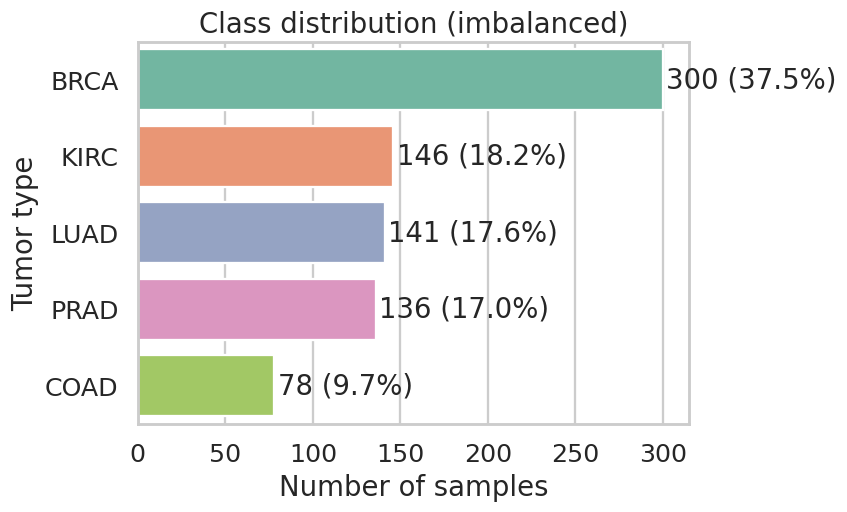

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
order = class_counts.index.tolist()
sns.barplot(x=class_counts.values, y=class_counts.index, order=order, palette=PALETTE, ax=ax)
for i, v in enumerate(class_counts.values):
    ax.text(v + 2, i, f"{v} ({100*v/class_counts.sum():.1f}%)", va="center")
ax.set(xlabel="Number of samples", ylabel="Tumor type", title="Class distribution (imbalanced)")
plt.tight_layout(); plt.show()

### 6.2 Per-sample total expression ("library size") by class
A check for systematic depth differences between classes that a model could exploit as a shortcut rather than learning biology.

sample_0      133742.948913
sample_1      128864.130049
sample_2      122275.042327
sample_3      129258.153464
sample_4      131890.743464
                  ...      
sample_796    129021.982629
sample_797    132617.544415
sample_798    145246.945578
sample_799    134725.418247
sample_800    134659.678052
Name: total_expression, Length: 801, dtype: float64

 Complete dataframe with the Total expression and class per each sample: 
            total_expression Class
sample_0       133742.948913  PRAD
sample_1       128864.130049  LUAD
sample_2       122275.042327  PRAD
sample_3       129258.153464  PRAD
sample_4       131890.743464  BRCA
...                      ...   ...
sample_796     129021.982629  BRCA
sample_797     132617.544415  LUAD
sample_798     145246.945578  COAD
sample_799     134725.418247  PRAD
sample_800     134659.678052  PRAD

[801 rows x 2 columns]





/tmp/ipykernel_7521/448399171.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lib, x="Class", y="total_expression", order=order, palette= "colorblind", ax=ax)


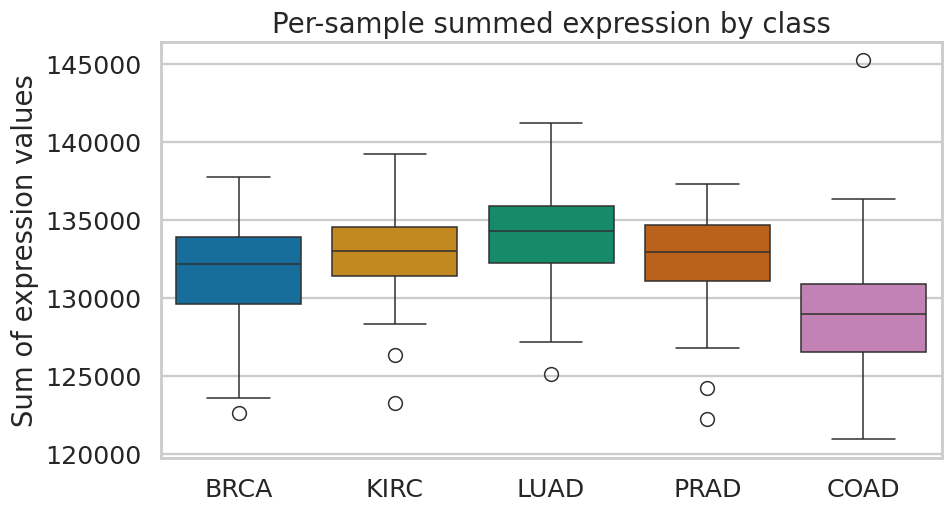

In [8]:
lib_size = X.sum(axis=1).rename("total_expression")
print(lib_size)
df_lib = pd.concat([lib_size, y_raw.rename("Class")], axis=1)
print("\n Complete dataframe with the Total expression and class per each sample: ")
print(df_lib)
print("\n\n")
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_lib, x="Class", y="total_expression", order=order, palette= "colorblind", ax=ax)
ax.set(title="Per-sample summed expression by class", xlabel="", ylabel="Sum of expression values")
plt.tight_layout(); plt.show()

### 6.3 Distribution of expression values
Most entries are zero or low; a smaller mass of moderately expressed genes carries the signal.

[0.         2.01720929 3.26552691 ... 9.84479363 4.55071601 0.        ]


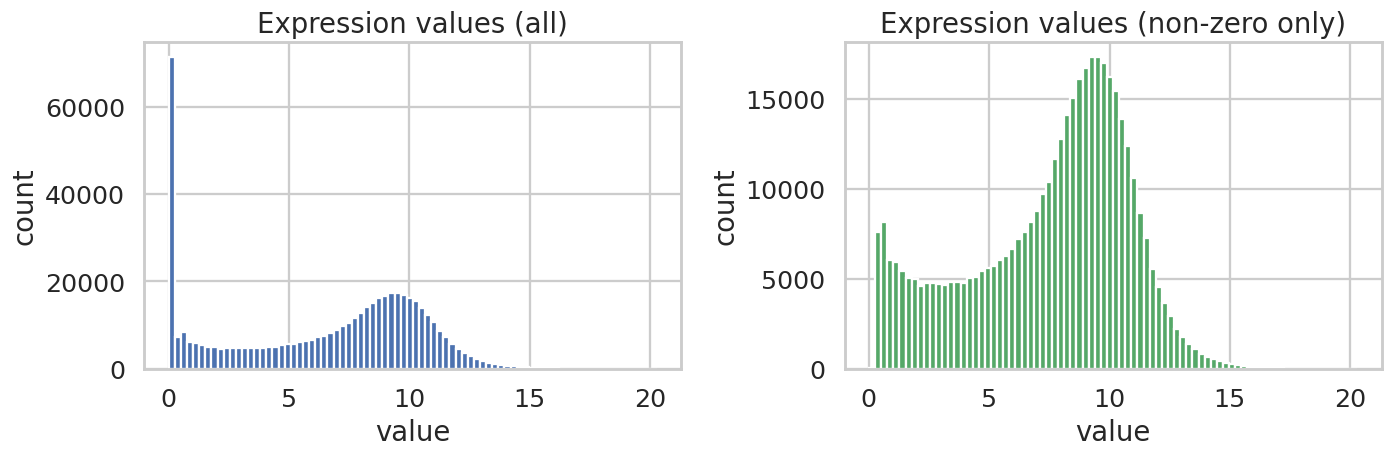

In [9]:
# Extract the underlying NumPy array from the Pandas DataFrame 'X' via '.values'
# and flatten it into a one-dimensional array using '.ravel()'. This combines
# all expression values across all samples and all 20,531 genes into a single continuous sequence.
sample_vals = X.values.ravel()
print(sample_vals)

# Initialize a reproducible random number generator with 'SEED' and randomly extract a subset
# from the flattened array. It chooses either 500,000 values or the maximum size of the array
# (whichever is smaller) without replacement (replace=False) to optimize plotting performance.
sample_vals = np.random.default_rng(SEED).choice(sample_vals, size=min(500_000, sample_vals.size), replace=False)

#Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(sample_vals, bins=80, color="#4C72B0")
axes[0].set(title="Expression values (all)", xlabel="value", ylabel="count")

#Remove the 0 expression values and plot again
axes[1].hist(sample_vals[sample_vals > 0], bins=80, color="#55A868")
axes[1].set(title="Expression values (non-zero only)", xlabel="value", ylabel="count")
plt.tight_layout(); plt.show()

### 6.4 Gene sparsity and variance
Many genes are silent (all/near-all zeros) or near-constant and carry no class information. The variance distribution motivates keeping only the top-variance genes.

In the following section the following are visualized:

1. Gene Zero Fraction (gene-zero-frac)For a specific gene $j$ (column $j$), the operation checks which sample rows contain an expression value of exactly zero and calculates their mean along the sample axis:

$$
\text{gene-zero-frac}_j = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(x_{ij} = 0)
$$

Where $\mathbb{I}(\cdot)$ is the indicator function defined as:$$\mathbb{I}(x_{ij} = 0) = \begin{cases} 1, & \text{if } x_{ij} = 0 \\ 0, & \text{if } x_{ij} \neq 0 \end{cases}
$$


2. Gene Variance (gene-var)Because $X$ is a Pandas DataFrame, the .var(axis=0) method defaults to calculating the sample variance (applying Bessel's correction with $N-1$ in the denominator) for each gene $j$ across all samples:

$$\text{gene-var}_j = \frac{1}{N-1} \sum_{i=1}^{N} (x_{ij} - \mu_j)^2$$

Where $\mu_j$ represents the sample mean of expression levels for gene $j$:$$\mu_j = \frac{1}{N} \sum_{i=1}^{N} x_{ij}$$




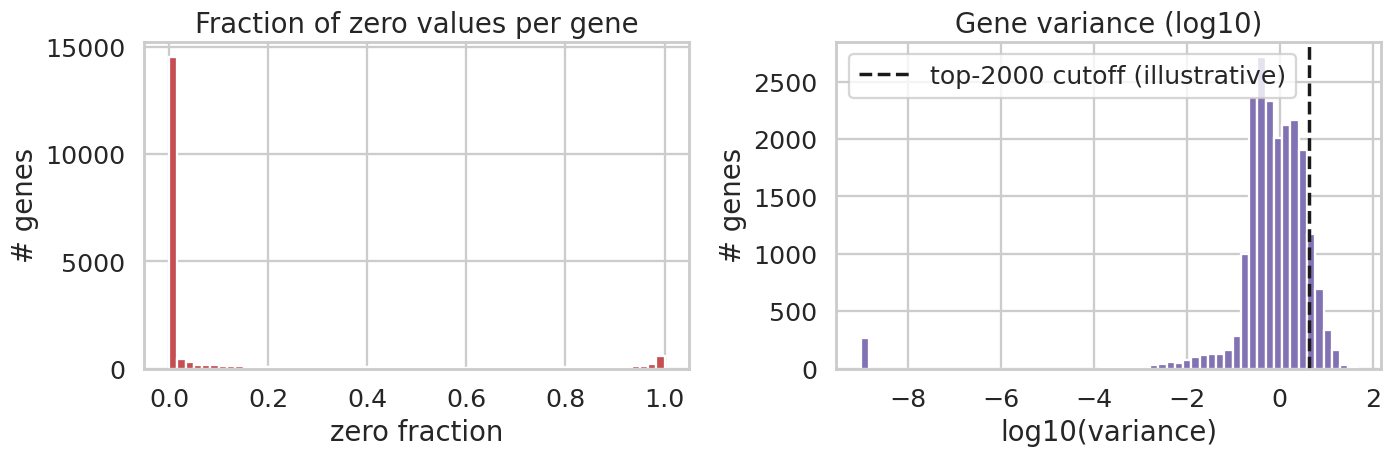

Genes that are entirely zero: 267
Genes with near-zero variance (<1e-6): 267


In [10]:
gene_zero_frac = (X == 0).mean(axis=0) # This is the n
gene_var       = X.var(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(gene_zero_frac, bins=60, color="#C44E52")
axes[0].set(title="Fraction of zero values per gene", xlabel="zero fraction", ylabel="# genes")
axes[1].hist(np.log10(gene_var + 1e-9), bins=60, color="#8172B3")
axes[1].axvline(np.log10(gene_var.sort_values(ascending=False).iloc[TOP_K_GENES] + 1e-9),
                color="k", ls="--", label=f"top-{TOP_K_GENES} cutoff (illustrative)")
axes[1].set(title="Gene variance (log10)", xlabel="log10(variance)", ylabel="# genes"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Genes that are entirely zero: {int((gene_zero_frac == 1).sum())}")
print(f"Genes with near-zero variance (<1e-6): {int((gene_var < 1e-6).sum())}")

### 6.5 Mean–variance relationship
Typical of expression data: variance grows with mean. Relevant because the scaler downstream removes this scale so no single high-magnitude gene dominates the MLP.

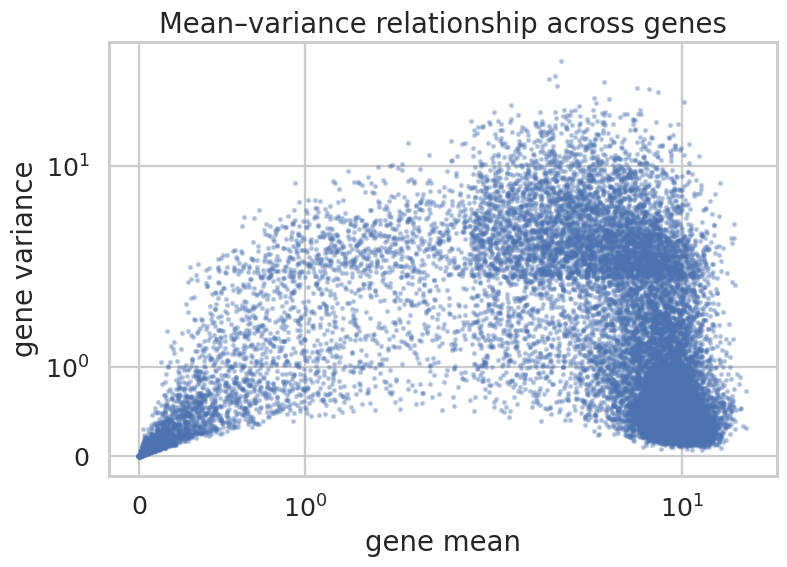

In [11]:
gene_mean = X.mean(axis=0)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(gene_mean, gene_var, s=4, alpha=0.3, color="#4C72B0")
ax.set(xlabel="gene mean", ylabel="gene variance", title="Mean–variance relationship across genes",
       xscale="symlog", yscale="symlog")
plt.tight_layout(); plt.show()

### 6.6 PCA — global structure
Linear projection of the full matrix. Clear class separation here suggests even a simple model will perform well; it also previews any class that overlaps heavily with another.

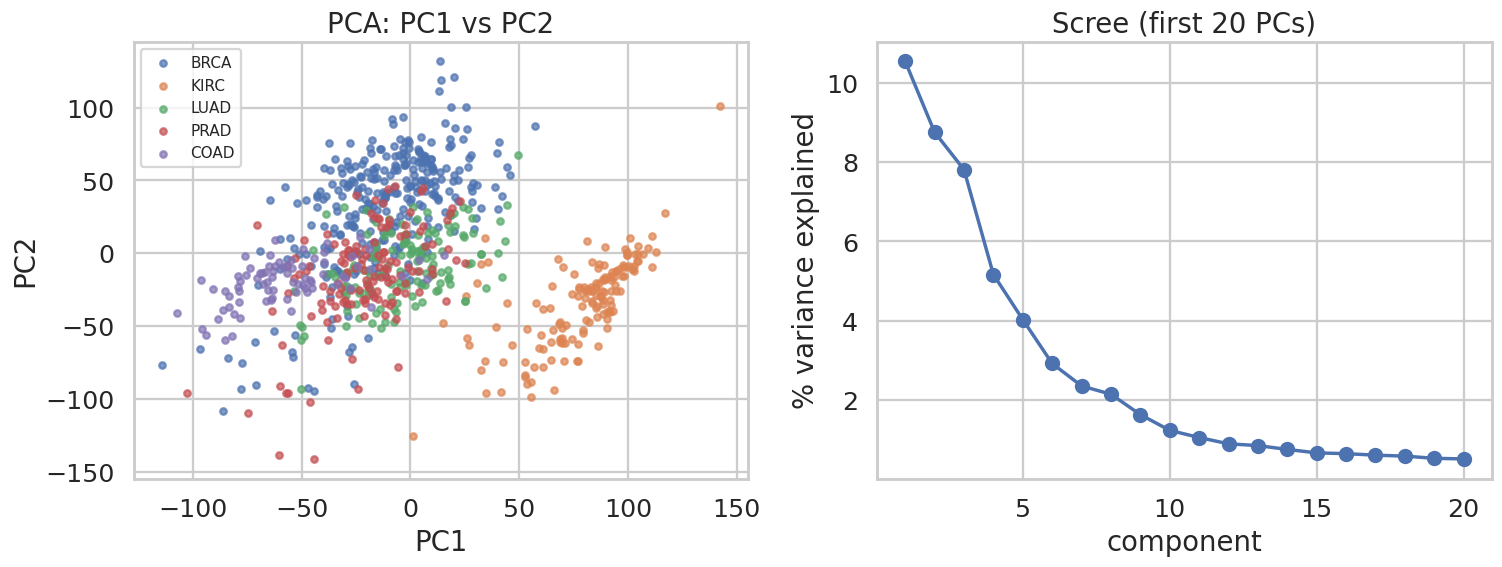

Variance explained by first 2 PCs: 19.3%


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as _SS

# EDA-only standardization on the full matrix (explicitly NOT reused for modeling).
#Standardize the entire feature matrix X (mean=0, variance=1 for each gene) and store it in X_eda.
X_eda = _SS().fit_transform(X.values)

pca = PCA(n_components=20, random_state=SEED).fit(X_eda)
pcs = pca.transform(X_eda)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for cls in order:
    m = (y_raw.values == cls)
    axes[0].scatter(pcs[m, 0], pcs[m, 1], s=18, alpha=0.7, label=cls)


axes[0].set(xlabel="PC1", ylabel="PC2", title="PCA: PC1 vs PC2"); axes[0].legend(fontsize=10)
axes[1].plot(range(1, 21), pca.explained_variance_ratio_*100, "o-")
axes[1].set(xlabel="component", ylabel="% variance explained", title="Scree (first 20 PCs)")
plt.tight_layout(); plt.show()
print("Variance explained by first 2 PCs: "
      f"{100*pca.explained_variance_ratio_[:2].sum():.1f}%")

### 6.7 t-SNE — local structure
Non-linear embedding for a clearer view of cluster compactness and any mixed samples.

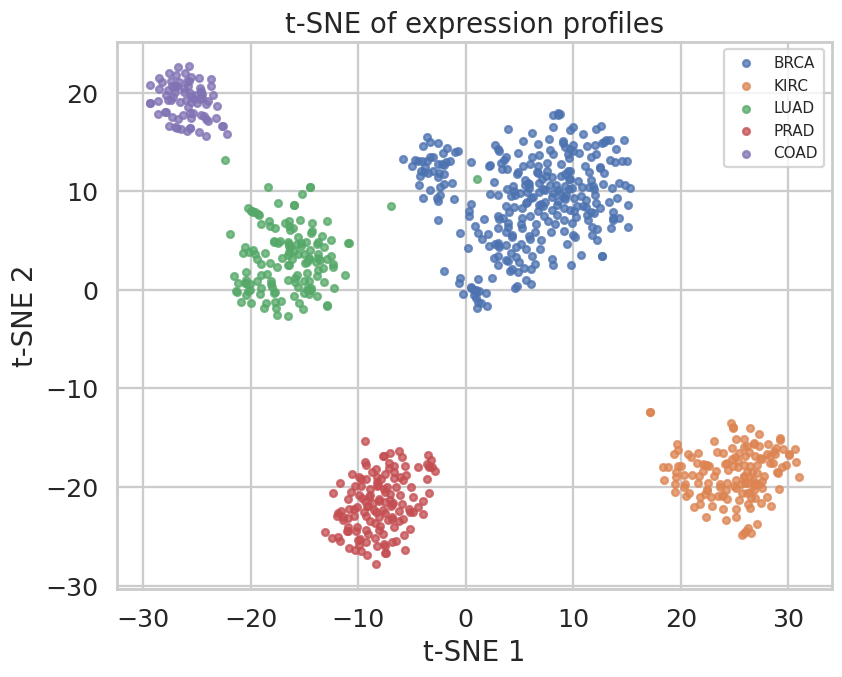

In [22]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED, learning_rate="auto")
emb = tsne.fit_transform(pcs[:, :50] if pcs.shape[1] >= 50 else X_eda)
fig, ax = plt.subplots(figsize=(8, 6.5))
for cls in order:
    m = (y_raw.values == cls)
    ax.scatter(emb[m, 0], emb[m, 1], s=20, alpha=0.75, label=cls)
ax.set(title="t-SNE of expression profiles", xlabel="t-SNE 1", ylabel="t-SNE 2"); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

### 6.8 Top-variance gene heatmap (clustered)
Rows = samples (annotated by class), columns = the most variable genes. Block structure aligning with class colors indicates discriminative genes exist.

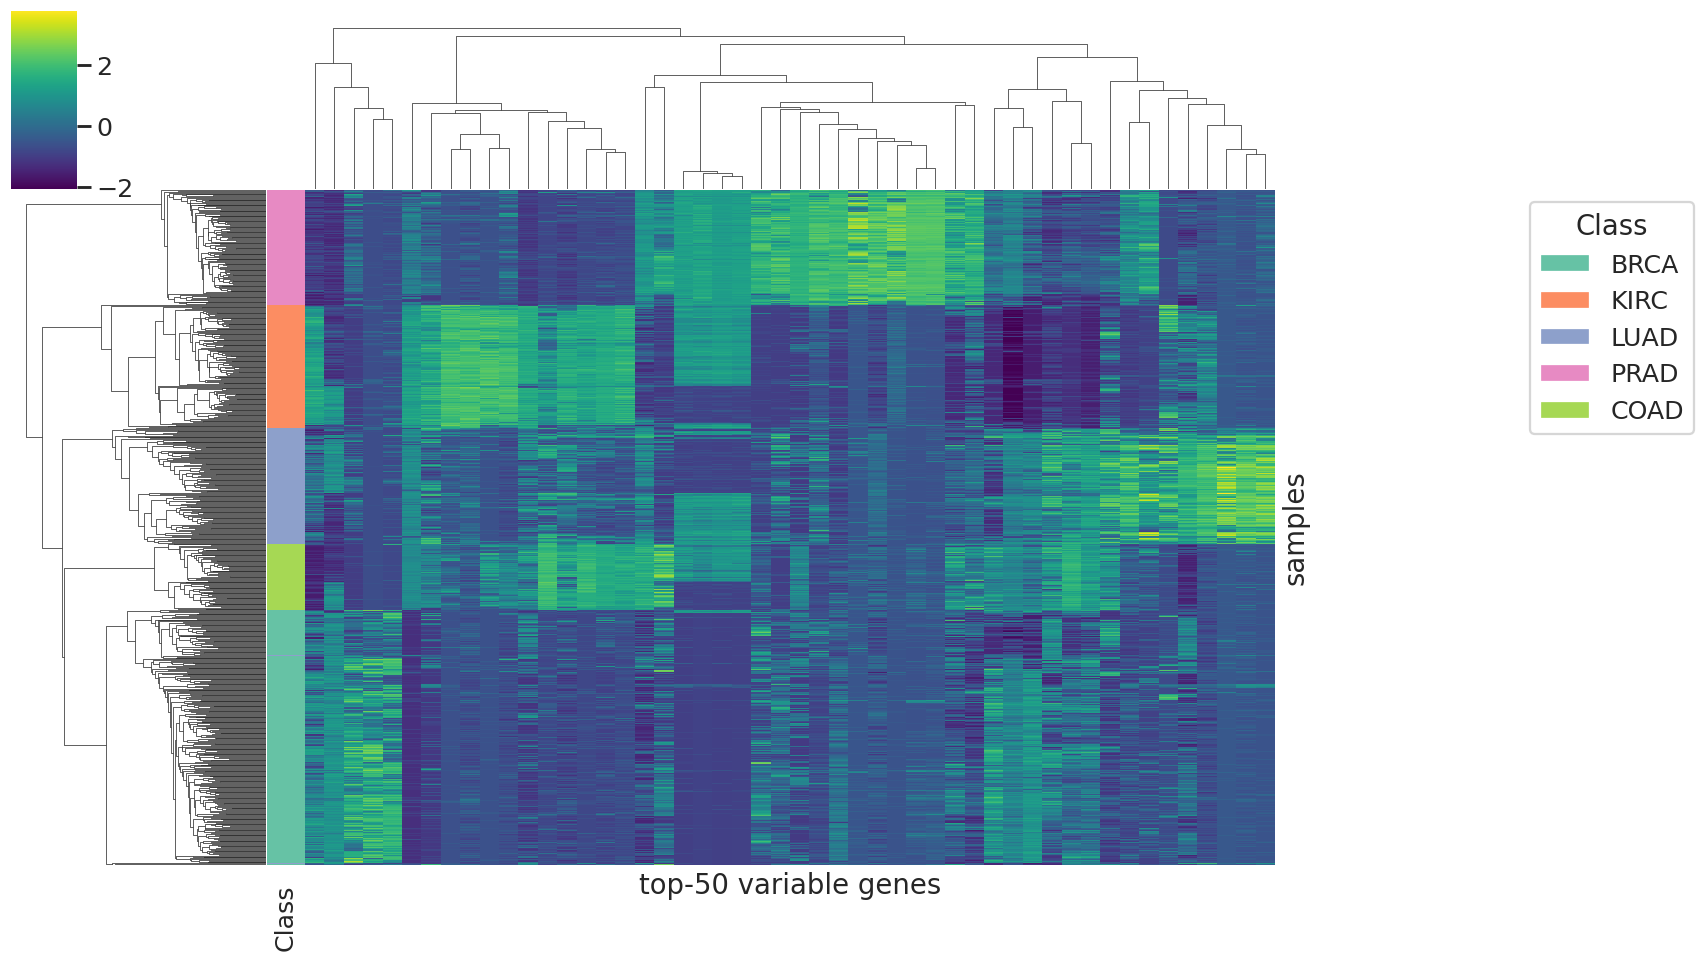

In [21]:
top_genes = gene_var.sort_values(ascending=False).head(50).index
lut = dict(zip(order, sns.color_palette(PALETTE, len(order))))
row_colors = y_raw.map(lut)
cg = sns.clustermap(X[top_genes], row_colors=row_colors, cmap="viridis",
                    z_score=1, figsize=(12, 9), xticklabels=False, yticklabels=False)
cg.ax_heatmap.set(xlabel="top-50 variable genes", ylabel="samples")
from matplotlib.patches import Patch
handles = [Patch(facecolor=lut[c], label=c) for c in order]
cg.ax_heatmap.legend(handles=handles, title="Class", bbox_to_anchor=(1.25, 1.0), loc="upper left")
plt.show()

### 6.9 Per-class mean expression of discriminative genes
Genes with the most variable *class means* are the ones a classifier leans on. This previews interpretability.

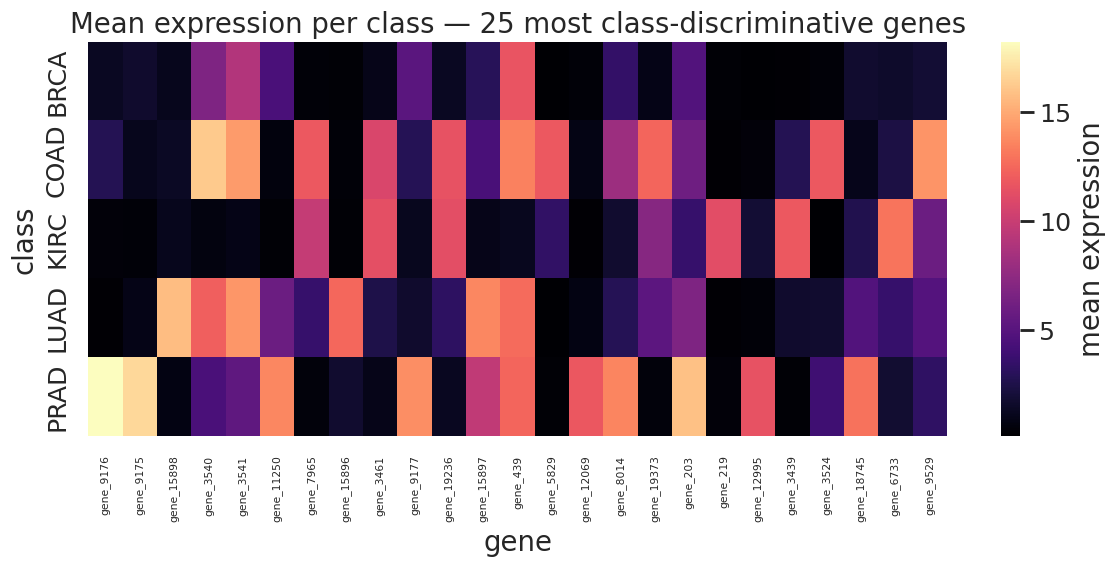

In [23]:
class_means = X.groupby(y_raw).mean()
discrim = class_means.var(axis=0).sort_values(ascending=False).head(25).index
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(class_means[discrim], cmap="magma", ax=ax, cbar_kws={"label": "mean expression"})
ax.set(title="Mean expression per class — 25 most class-discriminative genes",
       xlabel="gene", ylabel="class")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout(); plt.show()

## 7. Train / validation / test split

The split happens **before** any transform is fit. Stratification preserves the class proportions in every split so the minority class (`COAD`) is represented everywhere.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder().fit(y_raw)               # label encoding has no leakage risk (classes are known)
y = pd.Series(le.transform(y_raw), index=y_raw.index)
CLASS_NAMES = list(le.classes_)

idx = X.index.to_numpy()
idx_tmp, idx_test = train_test_split(idx, test_size=0.20, stratify=y.loc[idx], random_state=SEED)
idx_train, idx_val = train_test_split(idx_tmp, test_size=0.25, stratify=y.loc[idx_tmp], random_state=SEED)
# 0.25 * 0.80 = 0.20  ->  60 / 20 / 20

X_train_raw, X_val_raw, X_test_raw = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]

print(f"train {len(idx_train)} | val {len(idx_val)} | test {len(idx_test)}")
split_dist = pd.DataFrame({
    "train": y_train.map(dict(enumerate(CLASS_NAMES))).value_counts(normalize=True),
    "val":   y_val.map(dict(enumerate(CLASS_NAMES))).value_counts(normalize=True),
    "test":  y_test.map(dict(enumerate(CLASS_NAMES))).value_counts(normalize=True),
}).round(3)
print("\nClass proportions per split (stratification check):"); print(split_dist)

train 480 | val 160 | test 161

Class proportions per split (stratification check):
      train    val   test
BRCA  0.375  0.375  0.373
KIRC  0.181  0.181  0.186
LUAD  0.177  0.175  0.174
PRAD  0.171  0.169  0.168
COAD  0.096  0.100  0.099


## 8. Addressing any data-leakage

In the code below,

1. The splits are made sure to have no index overlap through assertion.
2. The dataset is scanned to identify and count completely identical sample rows using a duplication mask.
3. Row contents are hashed and grouped by their assigned split to verify that duplicate data samples do not appear across mutually exclusive sets (e.g., identical expression vectors existing in both the training and test splits), which would invalidate the evaluation metrics.

In [32]:
# 1. No index overlap between splits
assert set(idx_train) & set(idx_val)  == set(), "train/val overlap"
assert set(idx_train) & set(idx_test) == set(), "train/test overlap"
assert set(idx_val)   & set(idx_test) == set(), "val/test overlap"

# 2. Clean duplicate sample rows (identical expression vectors)
dup_mask = X.duplicated(keep=False)
print(dup_mask)
n_dupes  = int(dup_mask.sum())
print("\n Duplicate sample rows :", n_dupes, "\n")

# 3. Check and clean for ross-split duplicates specifically
hashes = pd.util.hash_pandas_object(X, index=False)
split_of = pd.Series("train", index=X.index)
split_of.loc[idx_val] = "val"; split_of.loc[idx_test] = "test"
cross_split_dupes = 0
for _, grp in pd.DataFrame({"h": hashes, "s": split_of}).groupby("h"):
    if grp["s"].nunique() > 1:
        cross_split_dupes += len(grp)

print(f"cross-split duplicates  {cross_split_dupes}"
      + ("  <-- investigate before trusting metrics" if cross_split_dupes else "  (clean)"))

sample_0      False
sample_1      False
sample_2      False
sample_3      False
sample_4      False
              ...  
sample_796    False
sample_797    False
sample_798    False
sample_799    False
sample_800    False
Length: 801, dtype: bool

 Duplicate sample rows : 0 

cross-split duplicates  0  (clean)


## 9. Preprocessing — fit on training data only

Two transforms, both fit on `X_train_raw`:

- **Variance gene filter:** keep the top `TOP_K_GENES` genes by *training-set* variance. Computing variance on the full matrix would leak test-set structure into feature selection.
- **Standardization:** zero-mean / unit-variance per gene, using *training* statistics, so the MLP and VAE see comparably scaled inputs and no high-magnitude gene dominates.

In [33]:
from sklearn.preprocessing import StandardScaler

# --- variance filter fit on TRAIN ---
train_var = X_train_raw.var(axis=0)
selected_genes = train_var.sort_values(ascending=False).head(TOP_K_GENES).index
print(f"Selected {len(selected_genes)} genes by training-set variance (from {X.shape[1]})")

X_train_sel = X_train_raw[selected_genes]
X_val_sel   = X_val_raw[selected_genes]
X_test_sel  = X_test_raw[selected_genes]

# --- scaler fit on TRAIN ---
scaler = StandardScaler().fit(X_train_sel)
X_train_s = scaler.transform(X_train_sel).astype("float32")
X_val_s   = scaler.transform(X_val_sel).astype("float32")
X_test_s  = scaler.transform(X_test_sel).astype("float32")

# class weights from TRAIN distribution (for imbalance)
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight("balanced", classes=np.arange(len(CLASS_NAMES)), y=y_train.values)
class_weights = torch.tensor(cw, dtype=torch.float32, device=DEVICE)
print("Per-class loss weights:", dict(zip(CLASS_NAMES, cw.round(3))))

Selected 2000 genes by training-set variance (from 20531)
Per-class loss weights: {'BRCA': np.float64(0.533), 'COAD': np.float64(2.087), 'KIRC': np.float64(1.103), 'LUAD': np.float64(1.129), 'PRAD': np.float64(1.171)}


## 10. Baseline — Random Forest

A strong, low-variance baseline that needs no scaling and gives free feature-importance. `class_weight="balanced"` handles imbalance. Tuned lightly on validation; reported on test in Section 11.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

rf = RandomForestClassifier(
    n_estimators=400, max_features="sqrt", class_weight="balanced",
    n_jobs=-1, random_state=SEED,
)
rf.fit(X_train_sel, y_train)                         # RF on selected (unscaled) genes

val_pred_rf = rf.predict(X_val_sel)
print(f"RF  val accuracy : {accuracy_score(y_val, val_pred_rf):.4f}")
print(f"RF  val macro-F1 : {f1_score(y_val, val_pred_rf, average='macro'):.4f}")

RF  val accuracy : 0.9938
RF  val macro-F1 : 0.9948


## 11. Deep model — regularized MLP (PyTorch)

A multi-layer perceptron on the standardized top-variance genes. Regularization is essential given $p \gg n$: **dropout (0.5)**, **batch-norm**, **weight decay**, and **early stopping** on validation macro-F1. The loss is class-weighted cross-entropy.

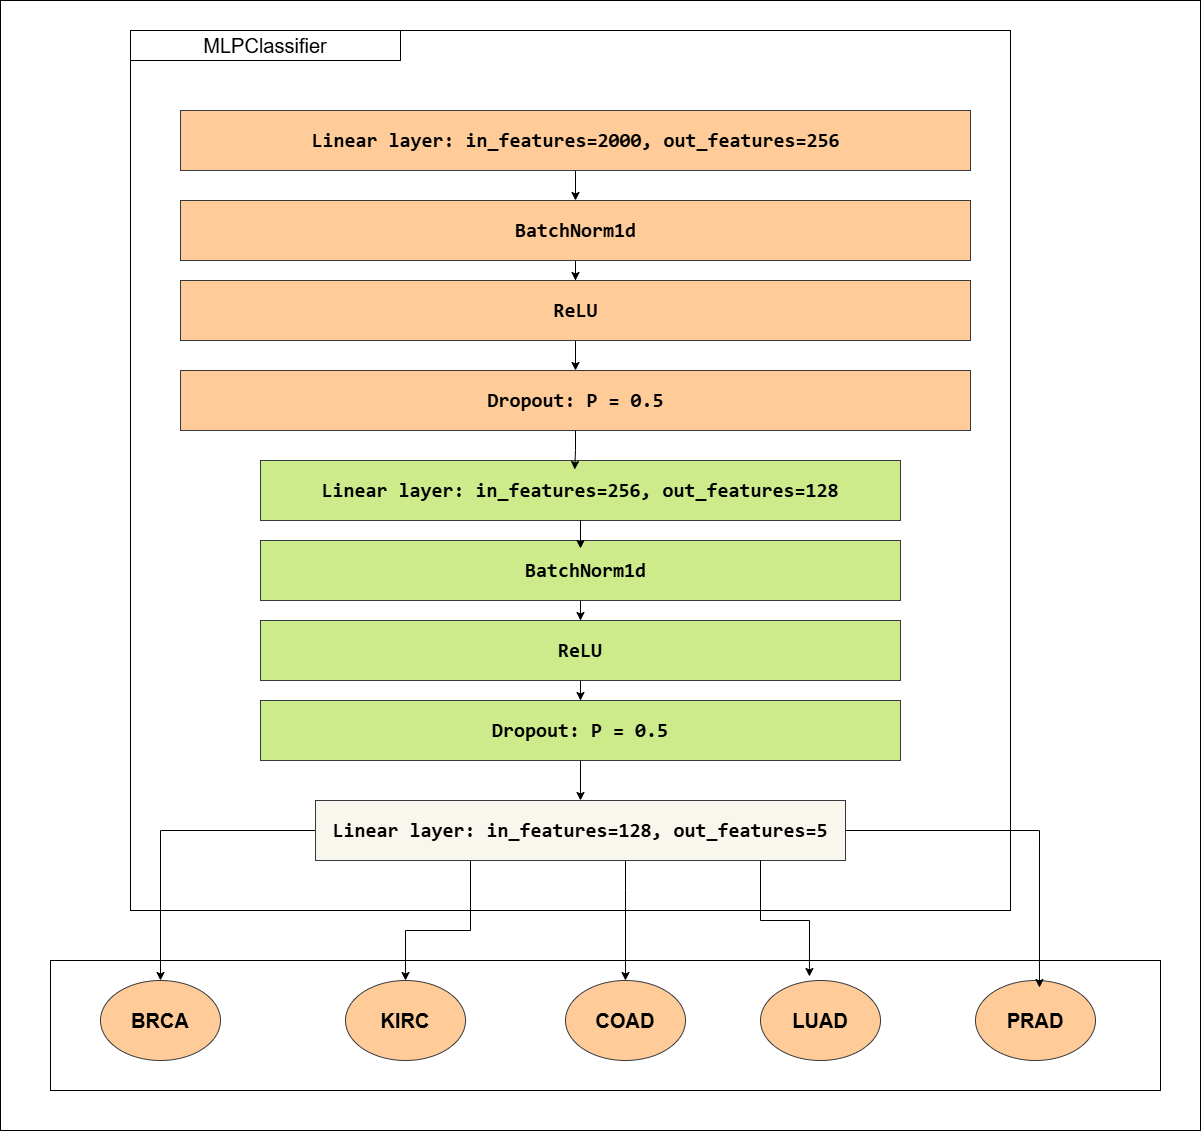

In [37]:
class MLPClassifier(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(256, 128), p_drop=0.5):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p_drop)]
            d = h
        layers += [nn.Linear(d, n_classes)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


def make_loader(Xa, ya, bs=64, shuffle=False):
    ds = TensorDataset(torch.tensor(Xa), torch.tensor(ya.values, dtype=torch.long))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

train_loader = make_loader(X_train_s, y_train, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val)

# Assuming X_train_s has 2000 features and there are 5 classes
mlp = MLPClassifier(in_dim=X_train_s.shape[1], n_classes=5)

# Standard PyTorch print
print(mlp)

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=2000, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=128, out_features=5, bias=True)
  )
)


In [38]:
def train_classifier(model, train_loader, val_loader, epochs, patience, weights, tag="model"):
    model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss(weight=weights)
    hist  = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_f1, best_state, wait = -1, None, 0

    for ep in range(epochs):
        model.train(); tot = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = lossf(model(xb), yb)
            loss.backward(); opt.step()
            tot += loss.item() * len(xb)
        tr_loss = tot / len(train_loader.dataset)

        model.eval(); vtot, preds, trues = 0.0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                vtot += lossf(out, yb).item() * len(xb)
                preds.append(out.argmax(1).cpu().numpy()); trues.append(yb.cpu().numpy())
        v_loss = vtot / len(val_loader.dataset)
        v_f1 = f1_score(np.concatenate(trues), np.concatenate(preds), average="macro")
        hist["train_loss"].append(tr_loss); hist["val_loss"].append(v_loss); hist["val_f1"].append(v_f1)

        if v_f1 > best_f1:
            best_f1, best_state, wait = v_f1, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  [{tag}] early stop at epoch {ep} (best val macro-F1 {best_f1:.4f})")
                break
    model.load_state_dict(best_state)
    return model, hist, best_f1

torch.manual_seed(SEED)
mlp = MLPClassifier(in_dim=X_train_s.shape[1], n_classes=len(CLASS_NAMES))
mlp, mlp_hist, mlp_best = train_classifier(mlp, train_loader, val_loader,
                                           MLP_EPOCHS, PATIENCE, class_weights, tag="MLP")
print(f"MLP val macro-F1 (best): {mlp_best:.4f}")

  [MLP] early stop at epoch 30 (best val macro-F1 1.0000)
MLP val macro-F1 (best): 1.0000


### 11.1 MLP learning curves
Here we have used early stopping to get the best check point

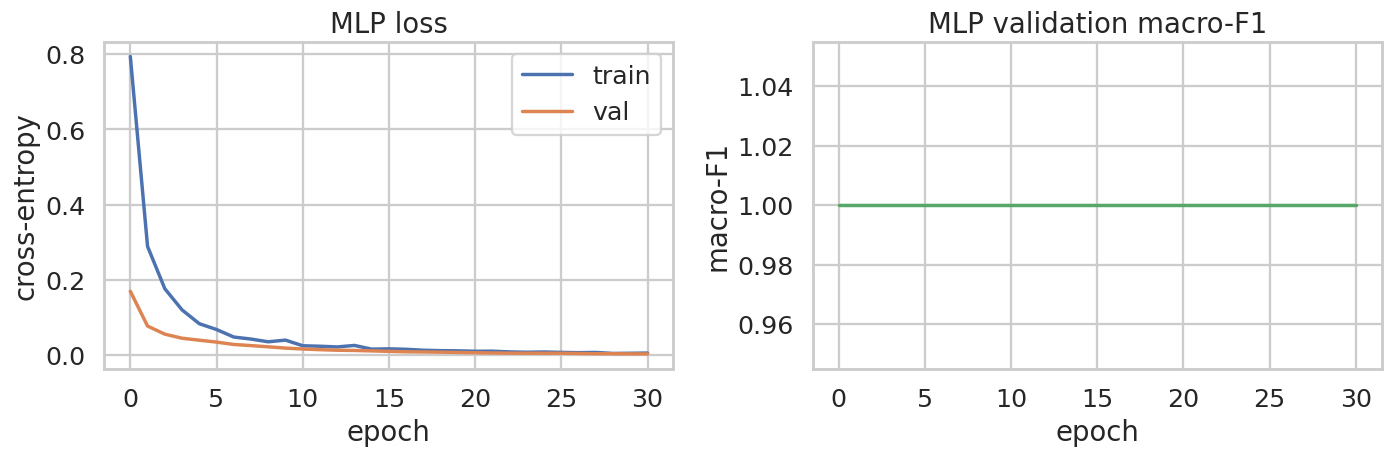

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(mlp_hist["train_loss"], label="train")
axes[0].plot(mlp_hist["val_loss"], label="val")
axes[0].set(title="MLP loss", xlabel="epoch", ylabel="cross-entropy"); axes[0].legend()
axes[1].plot(mlp_hist["val_f1"], color="#55A868")
axes[1].set(title="MLP validation macro-F1", xlabel="epoch", ylabel="macro-F1")
plt.tight_layout(); plt.show()

## 12. VAE-compressed latent + classifier

A Variational Autoencoder compresses the standardized genes into a low-dimensional latent space, which a small classifier then uses. Motivation: explicit dimensionality reduction before classification in the $p \gg n$ regime.

The VAE is trained **unsupervised on the training split only** (no labels, no val/test), then used to encode all splits. Loss is reconstruction (MSE, appropriate for standardized continuous inputs) plus a $\beta$-weighted KL term:

$$\mathcal{L} = \underbrace{\lVert x - \hat{x} \rVert^2}_{\text{reconstruction}} + \beta \cdot \underbrace{\big(-\tfrac{1}{2}\textstyle\sum_j (1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2)\big)}_{D_{KL}(q(z\mid x)\,\Vert\,\mathcal{N}(0,I))}$$

With only ~480 training samples, an unsupervised VAE will not necessarily beat a supervised model that selects discriminative genes directly. It is included to test the hypothesis.

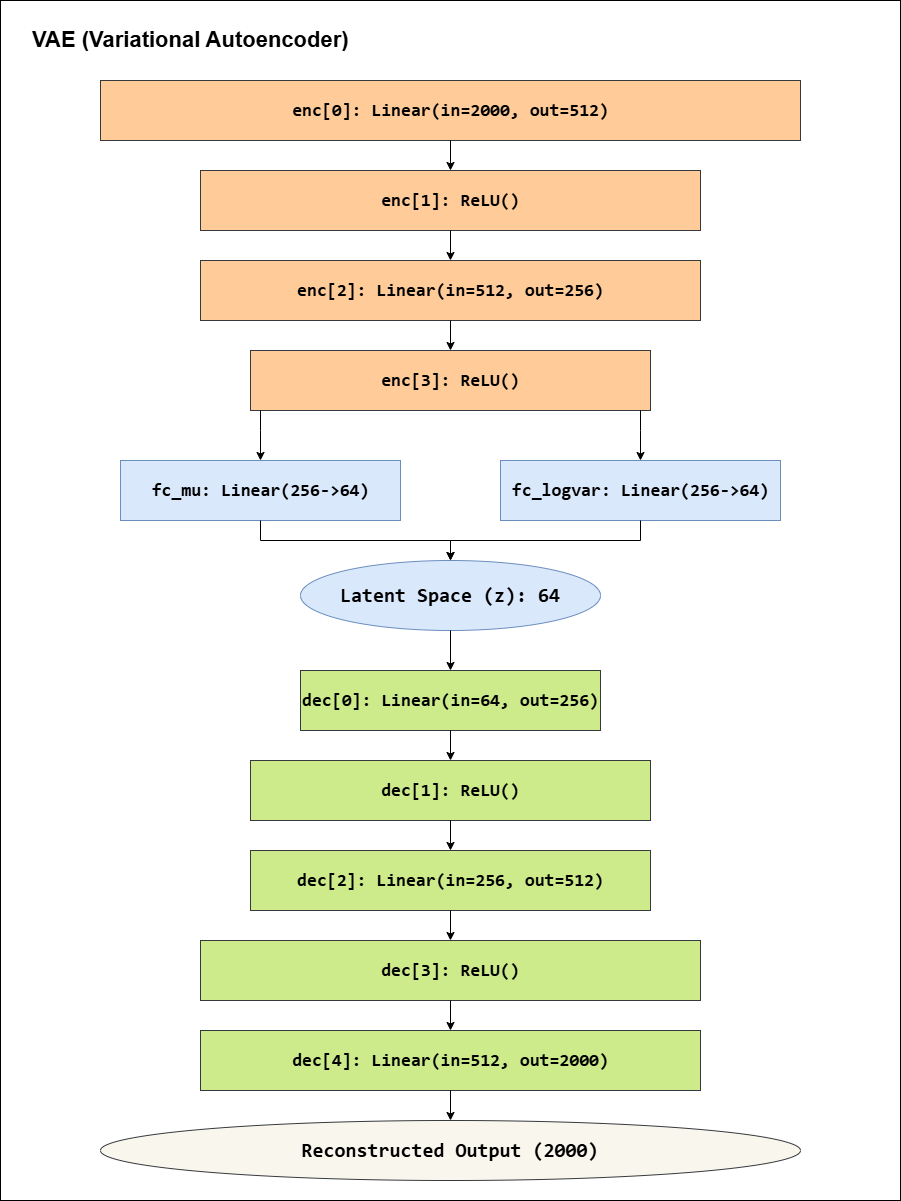

In [42]:
class VAE(nn.Module):
    def __init__(self, in_dim, hidden=512, latent=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden // 2), nn.ReLU())
        self.fc_mu     = nn.Linear(hidden // 2, latent)
        self.fc_logvar = nn.Linear(hidden // 2, latent)
        self.dec = nn.Sequential(nn.Linear(latent, hidden // 2), nn.ReLU(),
                                 nn.Linear(hidden // 2, hidden), nn.ReLU(),
                                 nn.Linear(hidden, in_dim))
    def encode(self, x):
        h = self.enc(x); return self.fc_mu(h), self.fc_logvar(h)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar); return mu + torch.randn_like(std) * std
    def decode(self, z):
        return self.dec(z)
    def forward(self, x):
        mu, logvar = self.encode(x); z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon = nn.functional.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kld   = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kld, recon, kld

LATENT_DIM = 64
torch.manual_seed(SEED)
vae = VAE(in_dim=X_train_s.shape[1], latent=LATENT_DIM).to(DEVICE)

print("\n Archiecture of VAE \n")
print(vae)
print("\n\n")


opt = torch.optim.AdamW(vae.parameters(), lr=1e-3, weight_decay=1e-5)

vae_train_loader = make_loader(X_train_s, y_train, bs=64, shuffle=True)  # labels ignored
vae_val_loader   = make_loader(X_val_s,   y_val,   bs=64)

vae_hist = {"train": [], "val": []}
best_vloss, best_vae_state, wait = np.inf, None, 0
for ep in range(VAE_EPOCHS):
    vae.train(); tot = 0.0
    for xb, _ in vae_train_loader:
        xb = xb.to(DEVICE); opt.zero_grad()
        xh, mu, lv = vae(xb)
        loss, _, _ = vae_loss(xh, xb, mu, lv, beta=1.0)
        loss.backward(); opt.step(); tot += loss.item() * len(xb)
    tr = tot / len(vae_train_loader.dataset)

    vae.eval(); vtot = 0.0
    with torch.no_grad():
        for xb, _ in vae_val_loader:
            xb = xb.to(DEVICE)
            xh, mu, lv = vae(xb)
            l, _, _ = vae_loss(xh, xb, mu, lv, beta=1.0); vtot += l.item() * len(xb)
    v = vtot / len(vae_val_loader.dataset)
    vae_hist["train"].append(tr); vae_hist["val"].append(v)
    if v < best_vloss - 1e-3:
        best_vloss, best_vae_state, wait = v, {k: t.cpu().clone() for k, t in vae.state_dict().items()}, 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"  [VAE] early stop at epoch {ep} (best val loss {best_vloss:.2f})"); break
vae.load_state_dict(best_vae_state)
print(f"VAE best val loss: {best_vloss:.2f}")


 Archiecture of VAE 

VAE(
  (enc): Sequential(
    (0): Linear(in_features=2000, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=64, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2000, bias=True)
  )
)



  [VAE] early stop at epoch 101 (best val loss 780.03)
VAE best val loss: 780.03


Latent shapes: (480, 64) (160, 64) (161, 64)


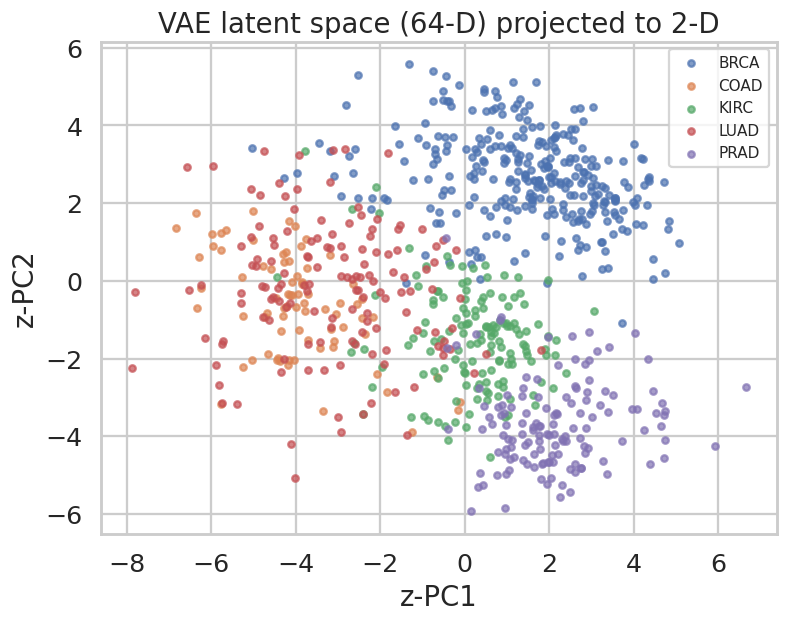

In [43]:
# Encode every split to the latent mean (deterministic) for the downstream classifier.
def encode_latent(model, Xa):
    model.eval()
    with torch.no_grad():
        mu, _ = model.encode(torch.tensor(Xa).to(DEVICE))
    return mu.cpu().numpy().astype("float32")

Z_train, Z_val, Z_test = encode_latent(vae, X_train_s), encode_latent(vae, X_val_s), encode_latent(vae, X_test_s)
print("Latent shapes:", Z_train.shape, Z_val.shape, Z_test.shape)

# Visualize latent space (PCA to 2D) coloured by class.
from sklearn.decomposition import PCA as _PCA
z2 = _PCA(n_components=2, random_state=SEED).fit_transform(np.vstack([Z_train, Z_val, Z_test]))
z_y = np.concatenate([y_train.values, y_val.values, y_test.values])
fig, ax = plt.subplots(figsize=(7.5, 6))
for ci, cls in enumerate(CLASS_NAMES):
    m = z_y == ci
    ax.scatter(z2[m, 0], z2[m, 1], s=18, alpha=0.7, label=cls)
ax.set(title=f"VAE latent space ({LATENT_DIM}-D) projected to 2-D", xlabel="z-PC1", ylabel="z-PC2")
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

In [44]:
# Classifier on the latent representation.
z_train_loader = make_loader(Z_train, y_train, shuffle=True)
z_val_loader   = make_loader(Z_val,   y_val)
torch.manual_seed(SEED)
latent_clf = MLPClassifier(in_dim=LATENT_DIM, n_classes=len(CLASS_NAMES), hidden=(64,), p_drop=0.3)
latent_clf, lat_hist, lat_best = train_classifier(latent_clf, z_train_loader, z_val_loader,
                                                  MLP_EPOCHS, PATIENCE, class_weights, tag="VAE-clf")
print(f"VAE+clf val macro-F1 (best): {lat_best:.4f}")

  [VAE-clf] early stop at epoch 43 (best val macro-F1 1.0000)
VAE+clf val macro-F1 (best): 1.0000


## 13. Evaluation on the held-out test set

 For each model report accuracy, macro-F1, weighted-F1, per-class precision/recall/F1, confusion matrices, and one-vs-rest ROC-AUC.

In [51]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score)
from scipy.special import softmax

def torch_predict(model, Xa):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(Xa).to(DEVICE)).cpu().numpy()
    return logits.argmax(1), softmax(logits, axis=1)

# Predictions on TEST
rf_pred  = rf.predict(X_test_sel);            rf_prob  = rf.predict_proba(X_test_sel)
mlp_pred, mlp_prob = torch_predict(mlp, X_test_s)
vae_pred, vae_prob = torch_predict(latent_clf, Z_test)

def summarise(name, y_true, y_pred, y_prob):
    return {
        "model": name,
        "accuracy":    accuracy_score(y_true, y_pred),
        "macro_f1":    f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "roc_auc_ovr": roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro"),
    }

results = pd.DataFrame([
    summarise("Random Forest", y_test, rf_pred,  rf_prob),
    summarise("MLP",           y_test, mlp_pred, mlp_prob),
    summarise("VAE + clf",     y_test, vae_pred, vae_prob),
]).set_index("model").round(4)
print("TEST-SET RESULTS\n"); print(results)

TEST-SET RESULTS

               accuracy  macro_f1  weighted_f1  roc_auc_ovr
model                                                      
Random Forest    0.9876    0.9893       0.9874          1.0
MLP              0.9938    0.9903       0.9938          1.0
VAE + clf        0.9938    0.9947       0.9938          1.0


### 13.1 Model comparison

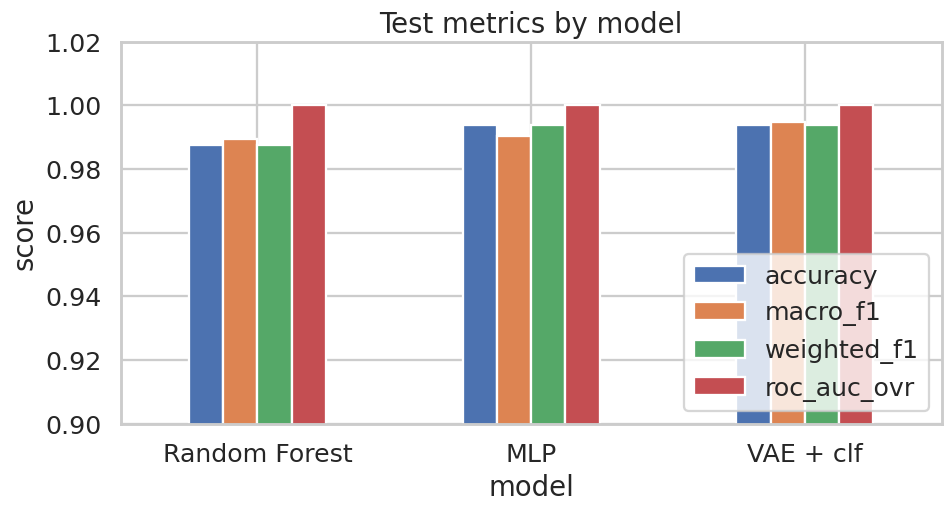

In [48]:
fig, ax = plt.subplots(figsize=(9, 5))
results[["accuracy", "macro_f1", "weighted_f1", "roc_auc_ovr"]].plot.bar(ax=ax)
ax.set(title="Test metrics by model", ylabel="score", ylim=(0.9, 1.02)); ax.legend(loc="lower right")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 13.2 Confusion matrices
Which tumor types get confused, and whether errors concentrate in the minority class.

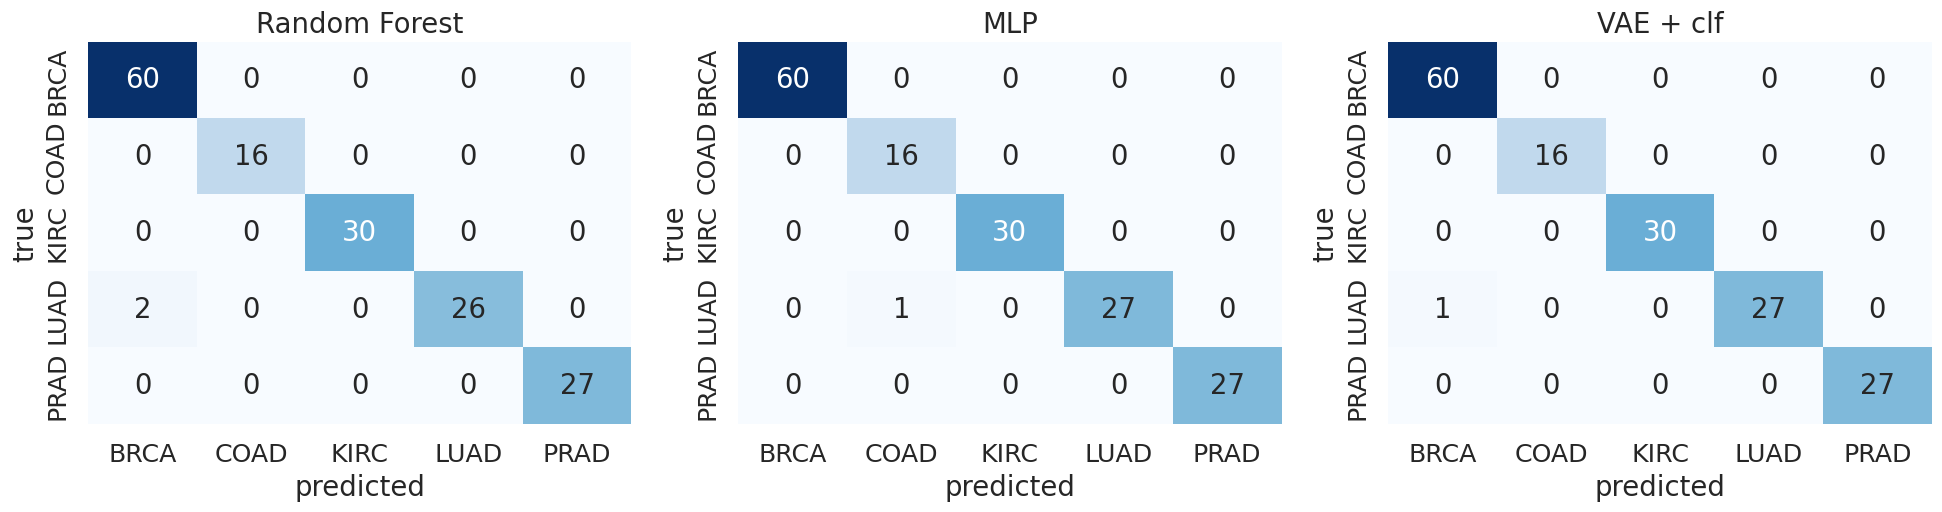

In [50]:
preds = {"Random Forest": rf_pred, "MLP": mlp_pred, "VAE + clf": vae_pred}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, p) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, p)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    ax.set(title=f"{name}", xlabel="predicted", ylabel="true")
plt.tight_layout(); plt.show()

### 13.3 Per-class report (best model by macro-F1)

Best model by macro-F1: VAE + clf

              precision    recall  f1-score   support

        BRCA      0.984     1.000     0.992        60
        COAD      1.000     1.000     1.000        16
        KIRC      1.000     1.000     1.000        30
        LUAD      1.000     0.964     0.982        28
        PRAD      1.000     1.000     1.000        27

    accuracy                          0.994       161
   macro avg      0.997     0.993     0.995       161
weighted avg      0.994     0.994     0.994       161



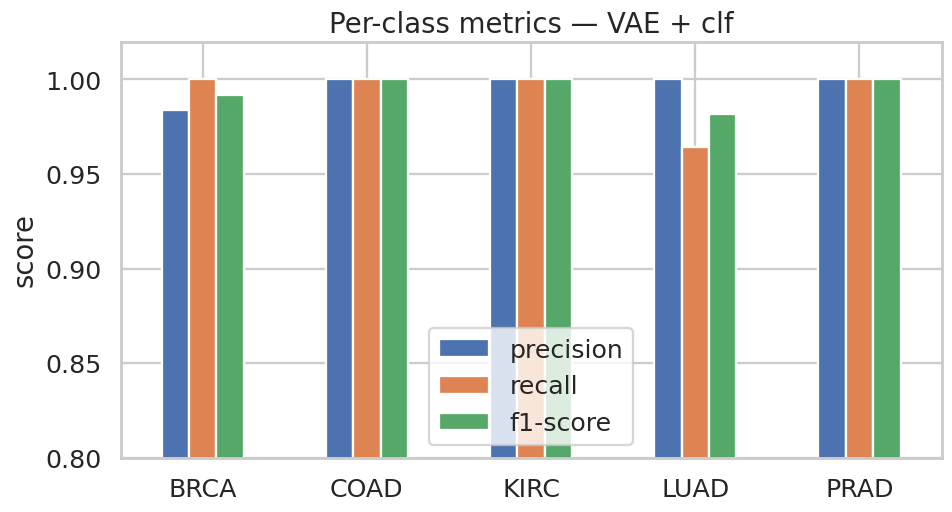

In [53]:
best_name = results["macro_f1"].idxmax()
best_pred = preds[best_name]
print(f"Best model by macro-F1: {best_name}\n")
print(classification_report(y_test, best_pred, target_names=CLASS_NAMES, digits=3))

rep = classification_report(y_test, best_pred, target_names=CLASS_NAMES, output_dict=True)
per_class = pd.DataFrame(rep).T.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]
fig, ax = plt.subplots(figsize=(9, 5))
per_class.plot.bar(ax=ax); ax.set(title=f"Per-class metrics — {best_name}", ylabel="score", ylim=(0.8, 1.02))
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 13.4 One-vs-rest ROC curves (best model)

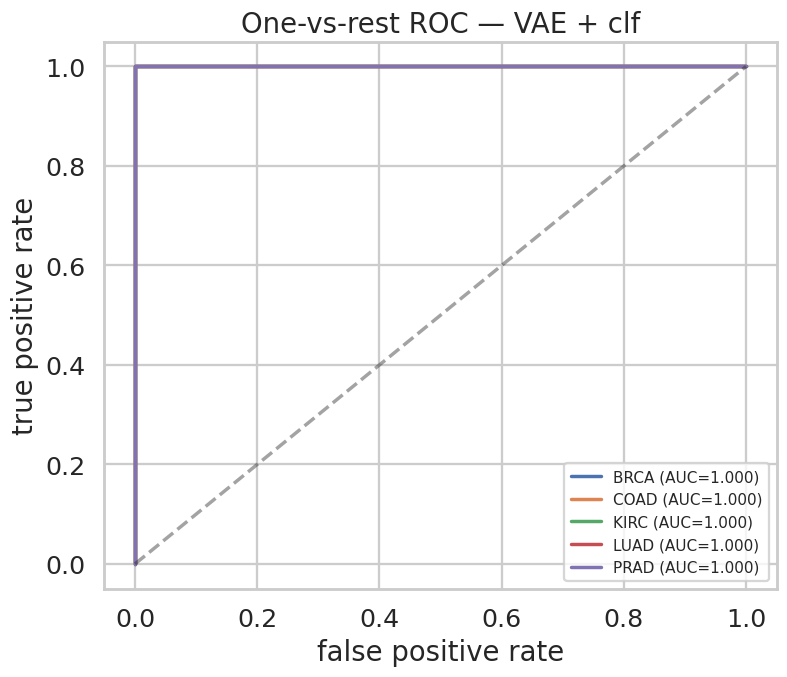

In [54]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
best_prob = {"Random Forest": rf_prob, "MLP": mlp_prob, "VAE + clf": vae_prob}[best_name]
y_bin = label_binarize(y_test, classes=range(len(CLASS_NAMES)))
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], best_prob[:, i])
    ax.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set(title=f"One-vs-rest ROC — {best_name}", xlabel="false positive rate", ylabel="true positive rate")
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

/tmp/ipykernel_7521/258358899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=ax)


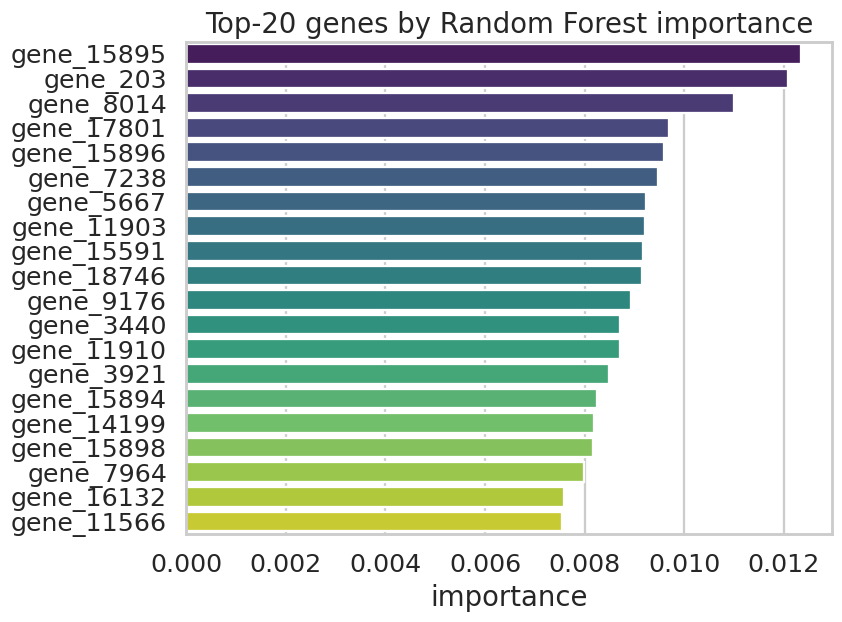

No single gene dominates -> signal is distributed (consistent with no obvious leakage):
  top gene importance = 0.0123, top-20 cumulative = 0.184


In [55]:
importances = pd.Series(rf.feature_importances_, index=selected_genes).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=ax)
ax.set(title="Top-20 genes by Random Forest importance", xlabel="importance", ylabel="")
plt.tight_layout(); plt.show()
print("No single gene dominates -> signal is distributed (consistent with no obvious leakage):")
print(f"  top gene importance = {importances.iloc[0]:.4f}, "
      f"top-20 cumulative = {importances.sum():.3f}")

## 14. Deployment

Persist everything needed for inference (selected gene list, scaler, label encoder, both models), then expose a single `predict_tumor_type` function that reproduces the exact training-time preprocessing on a raw expression vector.

In [56]:
import joblib
joblib.dump({
    "selected_genes": list(selected_genes),
    "scaler": scaler,
    "label_encoder": le,
    "rf_model": rf,
    "config": {"top_k_genes": TOP_K_GENES, "latent_dim": LATENT_DIM},
}, ARTIFACT_DIR / "preprocessing_and_rf.joblib")
torch.save(mlp.state_dict(),        ARTIFACT_DIR / "mlp_state.pt")
torch.save(vae.state_dict(),        ARTIFACT_DIR / "vae_state.pt")
torch.save(latent_clf.state_dict(), ARTIFACT_DIR / "latent_clf_state.pt")
print("Saved artifacts:", [p.name for p in ARTIFACT_DIR.iterdir()])

Saved artifacts: ['latent_clf_state.pt', 'vae_state.pt', 'mlp_state.pt', 'preprocessing_and_rf.joblib']


In [58]:
def predict_tumor_type(expr_row: pd.Series, model="mlp"):
    # Predict tumor type for one raw sample (index = original gene_* names).
    # Applies the exact training preprocessing: gene subset -> train scaler -> model.
    x = expr_row.reindex(selected_genes).fillna(0.0).values.reshape(1, -1)
    xs = scaler.transform(x).astype("float32")
    if model == "rf":
        proba = rf.predict_proba(xs if False else x)[0]   # RF uses unscaled selected genes
    elif model == "mlp":
        _, proba = torch_predict(mlp, xs); proba = proba[0]
    elif model == "vae":
        z = encode_latent(vae, xs); _, proba = torch_predict(latent_clf, z); proba = proba[0]
    else:
        raise ValueError("model must be 'rf', 'mlp', or 'vae'")
    k = int(np.argmax(proba))
    return {"prediction": CLASS_NAMES[k],
            "confidence": float(proba[k]),
            "probabilities": {c: round(float(v), 4) for c, v in zip(CLASS_NAMES, proba)}}

# Demo on a real held-out test sample.
demo_id = idx_test[0]
demo_pred = predict_tumor_type(X.loc[demo_id], model="mlp")
print(f"Sample {demo_id} | true = {CLASS_NAMES[int(y.loc[demo_id])]}")
print(json.dumps(demo_pred, indent=2))

Sample sample_516 | true = KIRC
{
  "prediction": "KIRC",
  "confidence": 0.6497128009796143,
  "probabilities": {
    "BRCA": 0.0514,
    "COAD": 0.0896,
    "KIRC": 0.6497,
    "LUAD": 0.0538,
    "PRAD": 0.1555
  }
}
